# 01 — Análisis Exploratorio de Datos (EDA)

## Objetivo
Entender la estructura, calidad y comportamiento de los datos de ventas
antes de construir cualquier modelo de forecasting.

## Preguntas a responder
1. ¿Qué período de tiempo cubre el dataset?
2. ¿Cuántas tiendas y familias de productos hay?
3. ¿Hay valores nulos o anomalías?
4. ¿Existe estacionalidad en las ventas?
5. ¿Qué variables externas pueden ser relevantes?

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


## 1. Carga de Datos

In [3]:
# Carga de datasets
train = pd.read_csv('../data/raw/train.csv')
stores = pd.read_csv('../data/raw/stores.csv')
oil = pd.read_csv('../data/raw/oil.csv')
holidays = pd.read_csv('../data/raw/holidays_events.csv')

print("Datasets cargados ✅")
print(f"Train:     {train.shape}")
print(f"Stores:    {stores.shape}")
print(f"Oil:       {oil.shape}")
print(f"Holidays:  {holidays.shape}")

Datasets cargados ✅
Train:     (3000888, 6)
Stores:    (54, 5)
Oil:       (1218, 2)
Holidays:  (350, 6)


## 2. Inspección Inicial

In [4]:
# Inspección del dataset principal
print("=== TRAIN ===")
print(train.head())
print("\n")
print(train.dtypes)

=== TRAIN ===
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE   0.00            0
1   1  2013-01-01          1   BABY CARE   0.00            0
2   2  2013-01-01          1      BEAUTY   0.00            0
3   3  2013-01-01          1   BEVERAGES   0.00            0
4   4  2013-01-01          1       BOOKS   0.00            0


id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object


In [5]:
# Inspección de los otros datasets
print("=== STORES ===")
print(stores.head())
print("\n=== OIL ===")
print(oil.head())
print("\n=== HOLIDAYS ===")
print(holidays.head())

=== STORES ===
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

=== OIL ===
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20

=== HOLIDAYS ===
         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3  2012-04-14  Holiday     Local    Li

## 3. Análisis de Valores Nulos

In [6]:
# Valores nulos por dataset
print("=== VALORES NULOS ===")
print("\nTrain:")
print(train.isnull().sum())
print("\nStores:")
print(stores.isnull().sum())
print("\nOil:")
print(oil.isnull().sum())
print("\nHolidays:")
print(holidays.isnull().sum())

=== VALORES NULOS ===

Train:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Stores:
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

Oil:
date           0
dcoilwtico    43
dtype: int64

Holidays:
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


## 4. Análisis Temporal

In [7]:
# Convertir fecha a datetime
train['date'] = pd.to_datetime(train['date'])

# Rango temporal del dataset
print("=== RANGO TEMPORAL ===")
print(f"Fecha inicio:  {train['date'].min()}")
print(f"Fecha fin:     {train['date'].max()}")
print(f"Días totales:  {(train['date'].max() - train['date'].min()).days}")
print(f"Años cubiertos: {round((train['date'].max() - train['date'].min()).days / 365, 1)}")

# Tiendas y familias únicas
print("\n=== DIMENSIONES DEL NEGOCIO ===")
print(f"Tiendas únicas:          {train['store_nbr'].nunique()}")
print(f"Familias de productos:   {train['family'].nunique()}")
print(f"Familias: {sorted(train['family'].unique())}")

=== RANGO TEMPORAL ===
Fecha inicio:  2013-01-01 00:00:00
Fecha fin:     2017-08-15 00:00:00
Días totales:  1687
Años cubiertos: 4.6

=== DIMENSIONES DEL NEGOCIO ===
Tiendas únicas:          54
Familias de productos:   33
Familias: ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']


## 5. Análisis de Ventas

In [8]:
# Estadísticas descriptivas de ventas
print("=== ESTADÍSTICAS DE VENTAS ===")
print(train['sales'].describe())

# Ventas en cero
ventas_cero = (train['sales'] == 0).sum()
total = len(train)
print(f"\nRegistros con ventas = 0: {ventas_cero} ({round(ventas_cero/total*100, 1)}%)")

=== ESTADÍSTICAS DE VENTAS ===
count   3000888.00
mean        357.78
std        1102.00
min           0.00
25%           0.00
50%          11.00
75%         195.85
max      124717.00
Name: sales, dtype: float64

Registros con ventas = 0: 939130 (31.3%)


### 📝 Interpretación

Al analizar las ventas encontramos se encuentran tres cosas importantes: primero, la mayoría de los registros 
tienen ventas bajas (la mitad vende 11 unidades o menos), pero existen picos extremos de hasta 
124717 unidades, probablemente en feriados o promociones masivas, lo que genera una distribución 
muy asimétrica. Segundo, el 31.3% de los registros tiene ventas igual a cero, lo que significa 
que casi 1 de cada 3 combinaciones de tienda-producto-día no registró ventas. Tercero, la alta 
variabilidad (desviación estándar de 1102 contra una media de 357) indica que las ventas se 
comportan de forma muy diferente entre productos y tiendas, lo cual es un desafío clave para 
el modelo de forecasting.

## 6. Visualización de Ventas Totales en el Tiempo

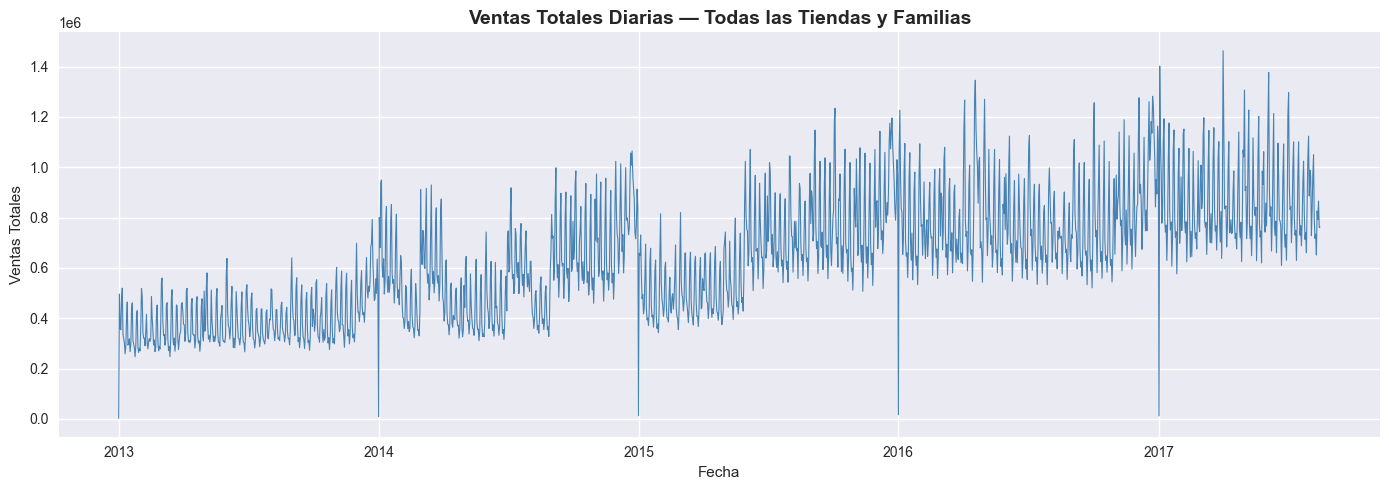

In [10]:
# Ventas diarias totales
ventas_diarias = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(ventas_diarias['date'], ventas_diarias['sales'], 
         color='steelblue', linewidth=0.8)
plt.title('Ventas Totales Diarias — Todas las Tiendas y Familias', 
          fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.tight_layout()
plt.savefig('../reports/figures/01_ventas_diarias.png', dpi=150)
plt.show()

### 📝 Interpretación

El gráfico muestra una tendencia creciente clara a lo largo de los 4,6 años, con ventas que 
pasaron de aproximadamente 400000 unidades diarias en 2013 a superar 1000000 en 2017. 
Se observan patrones estacionales repetidos año a año, caídas bruscas a cero que pueden deberse a ser feriados 
nacionales, y una alta variabilidad semanal.

## 7. Ventas Promedio por Día de la Semana

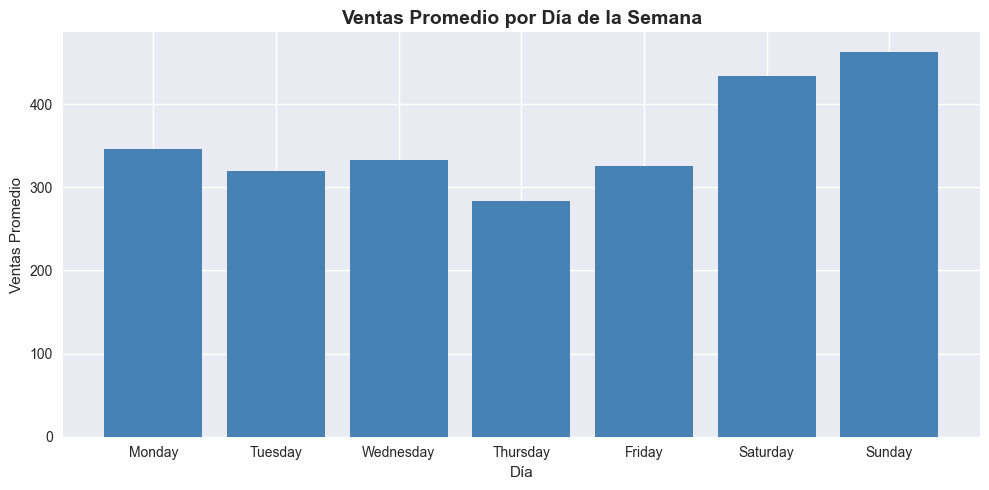

In [12]:
train['day_of_week'] = train['date'].dt.day_name()

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 
              'Thursday', 'Friday', 'Saturday', 'Sunday']

ventas_semana = train.groupby('day_of_week')['sales'].mean().reindex(orden_dias)

plt.figure(figsize=(10, 5))
bars = plt.bar(ventas_semana.index, ventas_semana.values, color='steelblue')
plt.title('Ventas Promedio por Día de la Semana', fontsize=14, fontweight='bold')
plt.xlabel('Día')
plt.ylabel('Ventas Promedio')
plt.tight_layout()
plt.savefig('../reports/figures/02_ventas_por_dia.png', dpi=150)
plt.show()

### 📝 Interpretación

Se confirma un patrón semanal muy claro: el fin de semana concentra las ventas más altas, 
con el domingo como día pico y el jueves como el más bajo. Este comportamiento es típico 
del retail de consumo masivo y deberá ser capturado por los modelos de forecasting 
mediante componentes de estacionalidad semanal.

## 8.Ventas promedio por mes

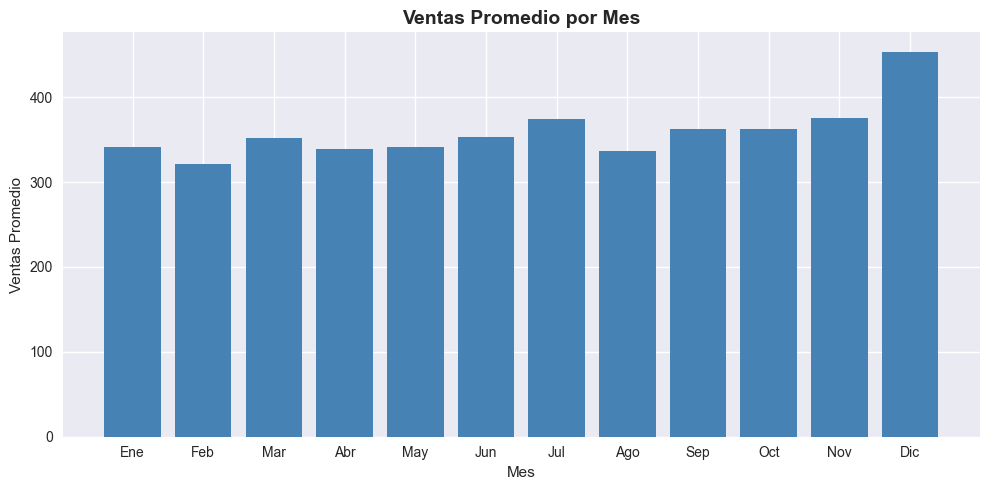

In [13]:
train['month'] = train['date'].dt.month

ventas_mes = train.groupby('month')['sales'].mean()

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(10, 5))
plt.bar(meses, ventas_mes.values, color='steelblue')
plt.title('Ventas Promedio por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Ventas Promedio')
plt.tight_layout()
plt.savefig('../reports/figures/03_ventas_por_mes.png', dpi=150)
plt.show()

### 📝 Interpretación

Se confirma estacionalidad anual con dos picos claros: diciembre como mes de mayor venta 
(navidad y fiestas) y julio como pico secundari. 
Febrero es consistentemente el mes más bajo. Esta estacionalidad anual, combinada con 
el patrón semanal anterior, confirma que los modelos deben capturar múltiples niveles 
de estacionalidad simultáneamente.

## 9. Top 10 Familias de Productos

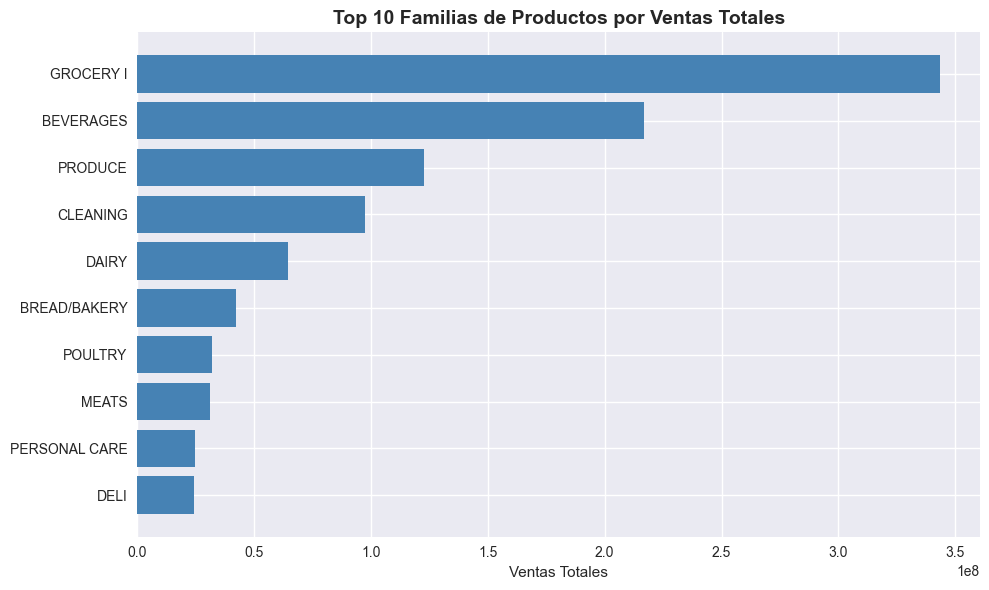

In [14]:
ventas_familia = train.groupby('family')['sales'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(ventas_familia.index, ventas_familia.values, color='steelblue')
plt.title('Top 10 Familias de Productos por Ventas Totales', fontsize=14, fontweight='bold')
plt.xlabel('Ventas Totales')
plt.tight_layout()
plt.savefig('../reports/figures/04_top_familias.png', dpi=150)
plt.show()

### 📝 Interpretación

Las ventas están fuertemente concentradas en pocas familias de productos. GROCERY I lidera 
ampliamente, seguido por BEVERAGES y PRODUCE. Este patrón de concentración, conocido como 
regla 80/20, implica que optimizar el forecast de las familias top tiene un impacto 
desproporcionadamente mayor en el negocio. En las fases siguientes se priorizará el modelado 
de las familias de mayor volumen.

## 10. Precio del Petróleo

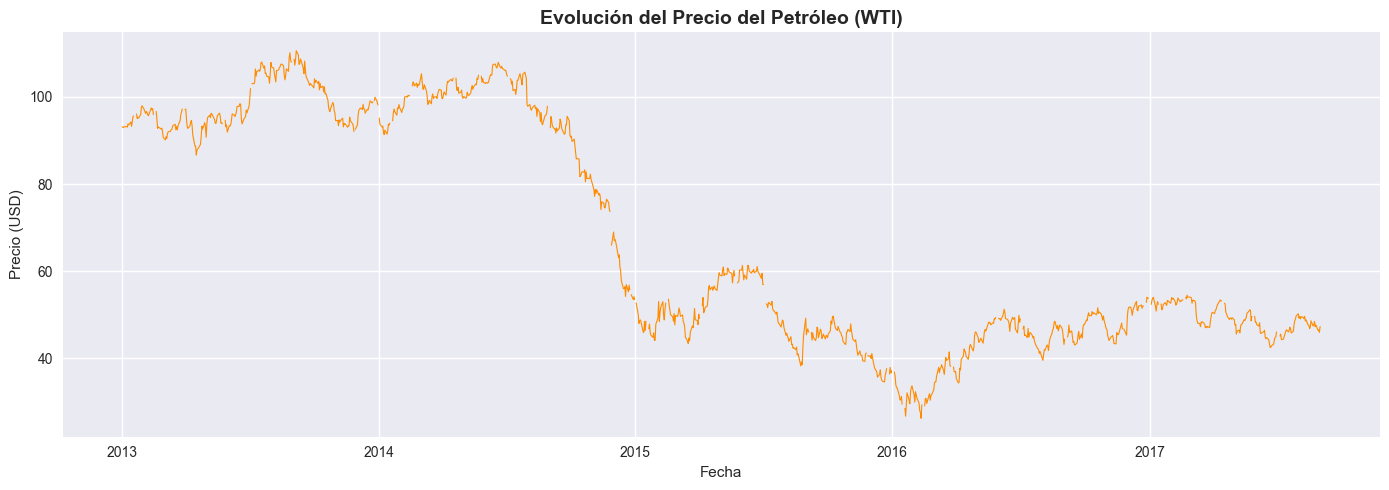

In [15]:
# Evolución del precio del petróleo
oil['date'] = pd.to_datetime(oil['date'])

plt.figure(figsize=(14, 5))
plt.plot(oil['date'], oil['dcoilwtico'], color='darkorange', linewidth=0.8)
plt.title('Evolución del Precio del Petróleo (WTI)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.tight_layout()
plt.savefig('../reports/figures/05_precio_petroleo.png', dpi=150)
plt.show()

### 📝 Interpretación

El precio del petróleo muestra una caída histórica entre 2014 y 2015, pasando de 
aproximadamente 100 USD a 45 USD. Dado que Ecuador es una economía dependiente del 
petróleo, esta variable puede explicar cambios estructurales en el consumo que no 
responden a patrones estacionales. Por esta razón se incluirá como variable externa 
en el modelo XGBoost.

## 11. Resumen Final del EDA

| | |
|---|---|
| **Período analizado** | 2013-01-01 → 2017-08-15 |
| **Años de datos** | 4.6 años |
| **Tiendas** | 54 |
| **Familias de productos** | 33 |
| **Total de registros** | 3.000.888 |

### ✅ Hallazgos Clave

- Tendencia creciente sostenida a lo largo de los 4.6 años.
- Estacionalidad semanal confirmada — el domingo es el día pico y el jueves el más bajo.
- Estacionalidad anual confirmada — diciembre es el mes pico y febrero el más bajo.
- Las ventas están concentradas en pocas familias — GROCERY I domina ampliamente (regla 80/20).
- El 31.3% de los registros tiene ventas = 0.

### ⚠️ Problemas Identificados

- 43 valores nulos en el precio del petróleo — requiere tratamiento antes del modelado.
- Caída macroeconómica 2014-2015 — evento estructural que puede afectar los modelos.
- La columna `date` estaba en formato string — ya corregida a datetime.